<a href="https://colab.research.google.com/github/kaviyarajadurai-krh/MLT-Tasks/blob/main/Usecase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Accuracy: 0.6666666666666666


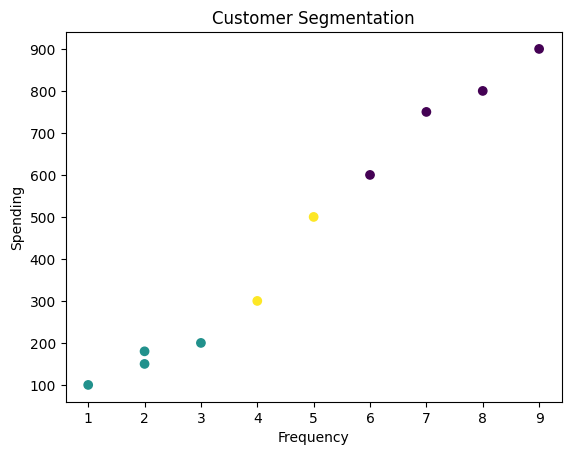

Perceptron Accuracy: 0.3333333333333333
Best Parameters: {'C': 1}
Best Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Sample dataset (you can replace with real dataset)
data = {
    'CustomerID': [1,2,3,4,5,6,7,8,9,10],
    'Purchase_Frequency': [5,3,6,2,8,7,1,4,9,2],
    'Total_Spending': [500,200,600,150,800,750,100,300,900,180],
    'Bought_Product': [1,0,1,0,1,1,0,0,1,0]
}

df = pd.DataFrame(data)

# ----------------------------
# DATA PREPROCESSING
# ----------------------------
df = df.drop_duplicates()

X = df[['Purchase_Frequency', 'Total_Spending']]
y = df['Bought_Product']

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# CLASSIFICATION
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Classification Accuracy:", accuracy_score(y_test, y_pred))

# ----------------------------
# CLUSTERING
# ----------------------------
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

# Plot clusters
plt.scatter(df['Purchase_Frequency'], df['Total_Spending'], c=clusters)
plt.xlabel("Frequency")
plt.ylabel("Spending")
plt.title("Customer Segmentation")
plt.show()

# ----------------------------
# PERCEPTRON MODEL
# ----------------------------
per_model = Perceptron()
per_model.fit(X_train, y_train)

per_pred = per_model.predict(X_test)
print("Perceptron Accuracy:", accuracy_score(y_test, per_pred))

# ----------------------------
# HYPERPARAMETER TUNING
# ----------------------------
param_grid = {'C': [0.1, 1, 10]}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)